In [1]:
import torch
from matplotlib import pyplot as plt
from torchvision.utils import make_grid
from diffusion.approaches.matching.prob_paths import (
    GaussianCondProbPath,
    LinearAlpha,
    LinearBeta,
)
from diffusion.sampleables.mnist_sampleable import MNISTSampleable
from diffusion.architectures.backbones.res_unet import ResUnet
from diffusion.approaches.matching.flow_generator import FlowGenerator, ScoreGenerator
from diffusion.architectures.classifiers.mnist_classifier import SimpleCNN


In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(device)

mps


In [3]:
sampeable = MNISTSampleable(train=True)

path = GaussianCondProbPath(
    p_data=sampeable,
    p_simple_shape=sampeable.shape,
    alpha=LinearAlpha(),
    beta=LinearBeta(),
).to(device)

backbone = ResUnet(
    in_channels=1,
    channels=[16, 32, 64],
    num_classes=sampeable.num_classes,
    t_dim=64,
    y_dim=32,
    cond_dim=64,
).to(device)
backbone.load_state_dict(torch.load("./models/backbone_flow_bili.pt"))

encoder = SimpleCNN(num_classes=sampeable.num_classes).to(device)
encoder.load_state_dict(torch.load("./models/classifier.pt"))

<All keys matched successfully>

100%|██████████| 29/29 [00:04<00:00,  5.90it/s]


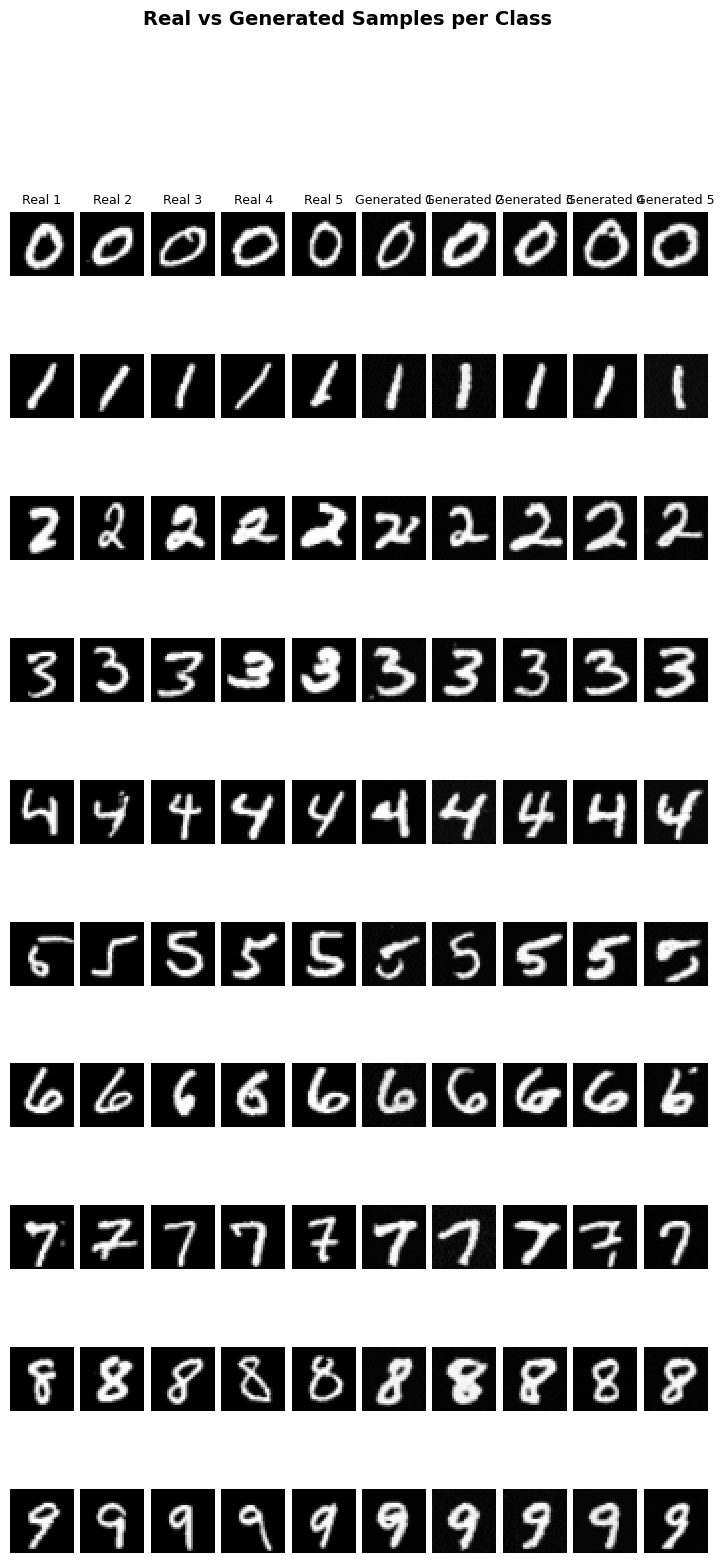

In [4]:
from diffusion.evaluation.evaluate import (
    compute_samples,
    evaluate_approach,
    plot_metrics_per_class,
    visualize_samples_per_class,
)


num_timesteps = 30
samples_per_class = 200
guidance_scale = 2.0

flow_generator = FlowGenerator(
    path=path,
    backbone=backbone,
    num_timesteps=num_timesteps,
    null_class=sampeable.num_classes,
    device=device,
)

p_data_test = MNISTSampleable(train=False)

x1_list, real_list = compute_samples(
    generator=flow_generator,
    p_data=p_data_test,
    samples_per_class=samples_per_class,
    num_classes=sampeable.num_classes,
    device=device,
    guidance_scale=guidance_scale,
)

visualize_samples_per_class(x1_list, real_list)

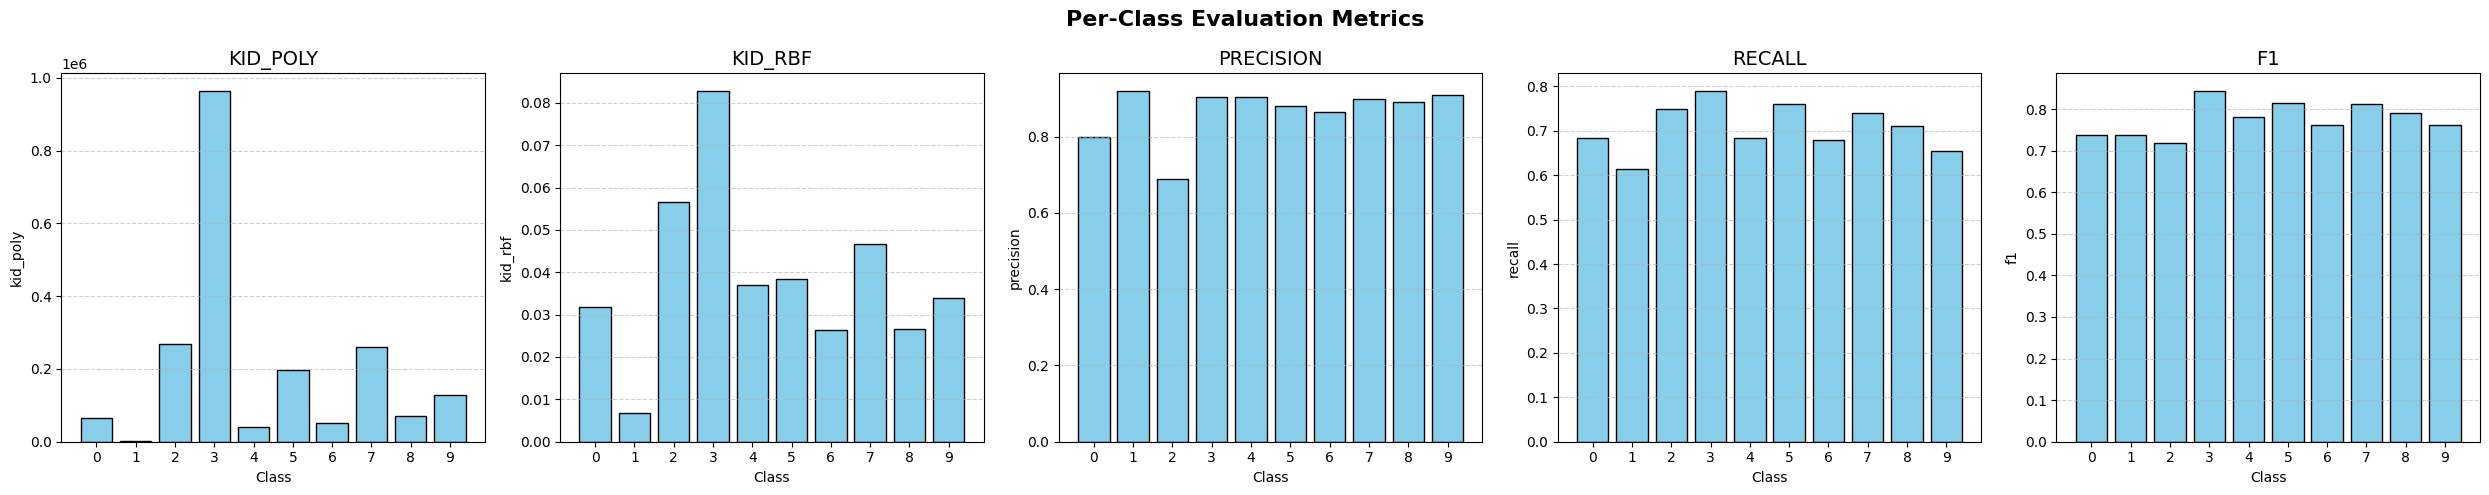

In [5]:
metrics_per_class = evaluate_approach(
    x1_list=x1_list, real_list=real_list, encoder=encoder
)

plot_metrics_per_class(metrics_per_class)

  0%|          | 0/9 [00:00<?, ?it/s]

100%|██████████| 9/9 [00:00<00:00, 10.42it/s]


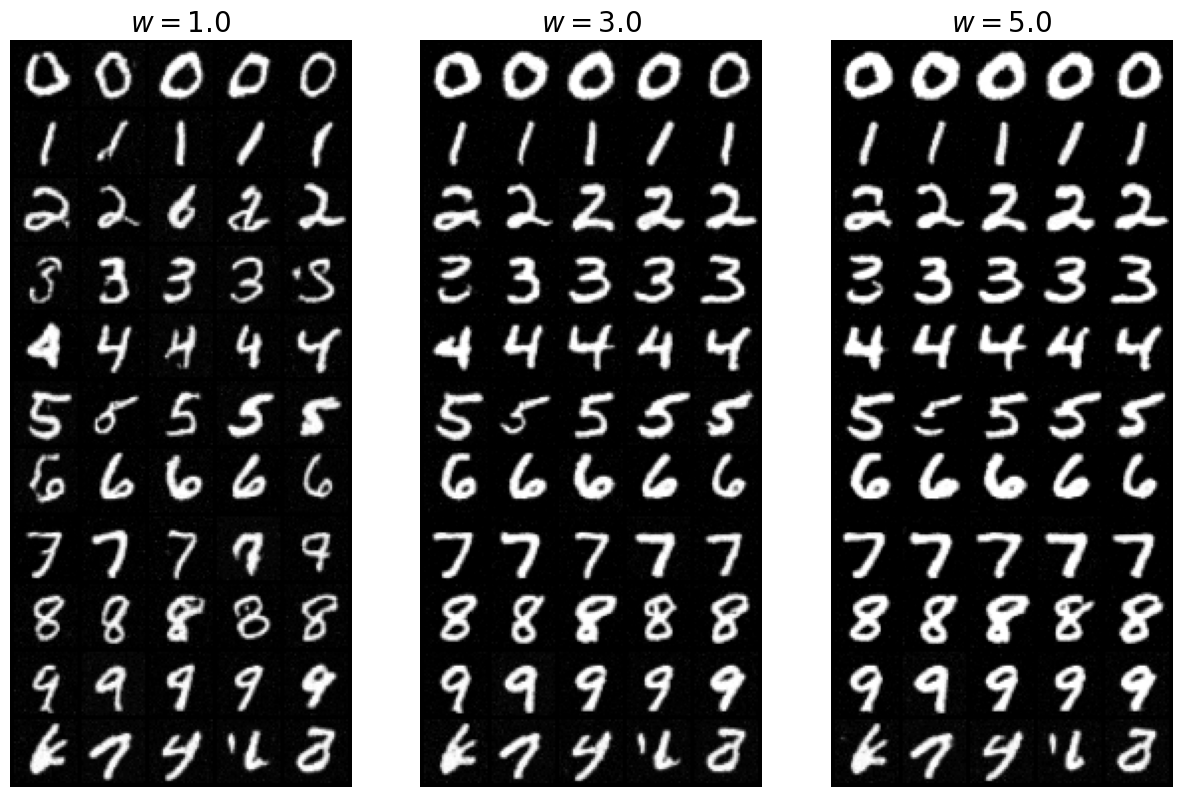

In [5]:
num_timesteps = 10
samples_per_class = 5
guidance_scales = [1.0, 3.0, 5.0]

y = (
    torch.tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
    .repeat_interleave(samples_per_class)
    .to(device)
)

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(guidance_scales),
    figsize=(samples_per_class * len(guidance_scales), 10),
)

flow_generator = ScoreGenerator(
    path=path,
    backbone=backbone,
    num_timesteps=num_timesteps,
    null_class=sampeable.num_classes,
    device=device,
)

x0 = flow_generator.sample_prior(
    num_samples=y.shape[0], shape=sampeable.shape, device=device
)
# (num_samples, 1, 32, 32)

for idx, w in enumerate(guidance_scales):
    x1 = flow_generator.generate(y, x0, w)

    grid = make_grid(x1, nrow=samples_per_class, normalize=True, value_range=(-1, 1))
    axes[idx].imshow(grid.permute(1, 2, 0).cpu(), cmap="gray")
    axes[idx].axis("off")
    axes[idx].set_title(f"$w={w:.1f}$", fontsize=20)

plt.show()